# 01 · Customer Churn & Retention Analyzer

**Objective:** Predict which customers will churn and explain *why*, so the business can act before they leave. Combines an ML classifier with an LLM insight layer.

## 1. Business Question
A subscription business bleeds revenue when customers leave. This project answers: **who is likely to churn, what drives it, and what should we do this quarter?** Stakeholders: the retention / CRM team.

In [1]:
import sys, os
sys.path.insert(0, '..')            # repo root, for utils/
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
from utils.ai_insights import generate_insights

if not os.path.exists('data/churn.csv'):
    import subprocess
    subprocess.run([sys.executable, 'generate_data.py'], check=True)

df = pd.read_csv('data/churn.csv')
print('shape :', df.shape)
print(df.head())
print('churn rate:', f"{df['Churn'].mean():.1%}")

shape : (5000, 10)
   tenure  MonthlyCharges        Contract InternetService TechSupport  \
0       7           23.39        One year     Fiber optic         Yes   
1      56           88.30        One year             DSL          No   
2      48          115.05  Month-to-month             DSL         Yes   
3      32          102.92  Month-to-month              No          No   
4      32           47.72        One year     Fiber optic         Yes   

  OnlineSecurity     PaymentMethod  SeniorCitizen  Dependents  Churn  
0             No      Mailed check              1           0      0  
1            Yes  Electronic check              1           0      0  
2            Yes      Mailed check              1           0      1  
3             No     Bank transfer              1           0      1  
4            Yes      Mailed check              0           0      0  
churn rate: 42.4%


## 2. Data & Dictionary
Synthetic but realistic subscription dataset (5,000 customers), generated by `generate_data.py` with a fixed seed → identical every run. This keeps the project free, reproducible, and interview-safe (no broken downloads).

Key columns: `tenure` (months), `MonthlyCharges`, `Contract`, `InternetService`, `TechSupport`, `OnlineSecurity`, `PaymentMethod`, `SeniorCitizen`, `Dependents`, `Churn` (1 = left).

tenure               int64
MonthlyCharges     float64
Contract            object
InternetService     object
TechSupport         object
OnlineSecurity      object
PaymentMethod       object
SeniorCitizen        int64
Dependents           int64
Churn                int64
dtype: object
missing values: 0


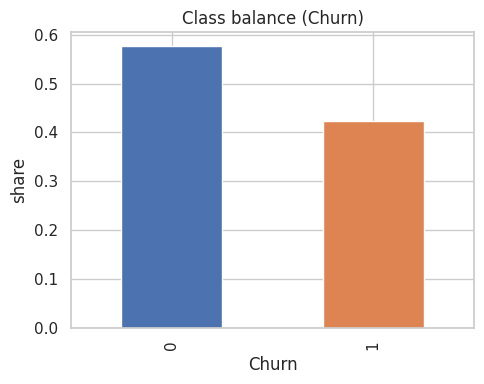

In [2]:
print(df.dtypes)
print('missing values:', int(df.isna().sum().sum()))
fig, ax = plt.subplots(figsize=(5,4))
df['Churn'].value_counts(normalize=True).plot(kind='bar', ax=ax, color=['#4C72B0','#DD8452'])
ax.set_title('Class balance (Churn)'); ax.set_ylabel('share')
plt.tight_layout(); plt.savefig('assets/balance.png', dpi=110); plt.show()

## 3. Cleaning & Preparation
The data is already tidy (no missing values, correct types). We split into train/test with stratification to keep churn proportions, and build a preprocessing pipeline that one-hot encodes categoricals.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_curve)

X = df.drop('Churn', axis=1); y = df['Churn']
cat = ['Contract','InternetService','TechSupport','OnlineSecurity','PaymentMethod']
num = ['tenure','MonthlyCharges','SeniorCitizen','Dependents']
pre = ColumnTransformer([('cat', OneHotEncoder(handle_unknown='ignore'), cat)], remainder='passthrough')
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## 4. Exploratory Analysis
Churn rate by the main drivers. Bars/line make the story obvious to any stakeholder.

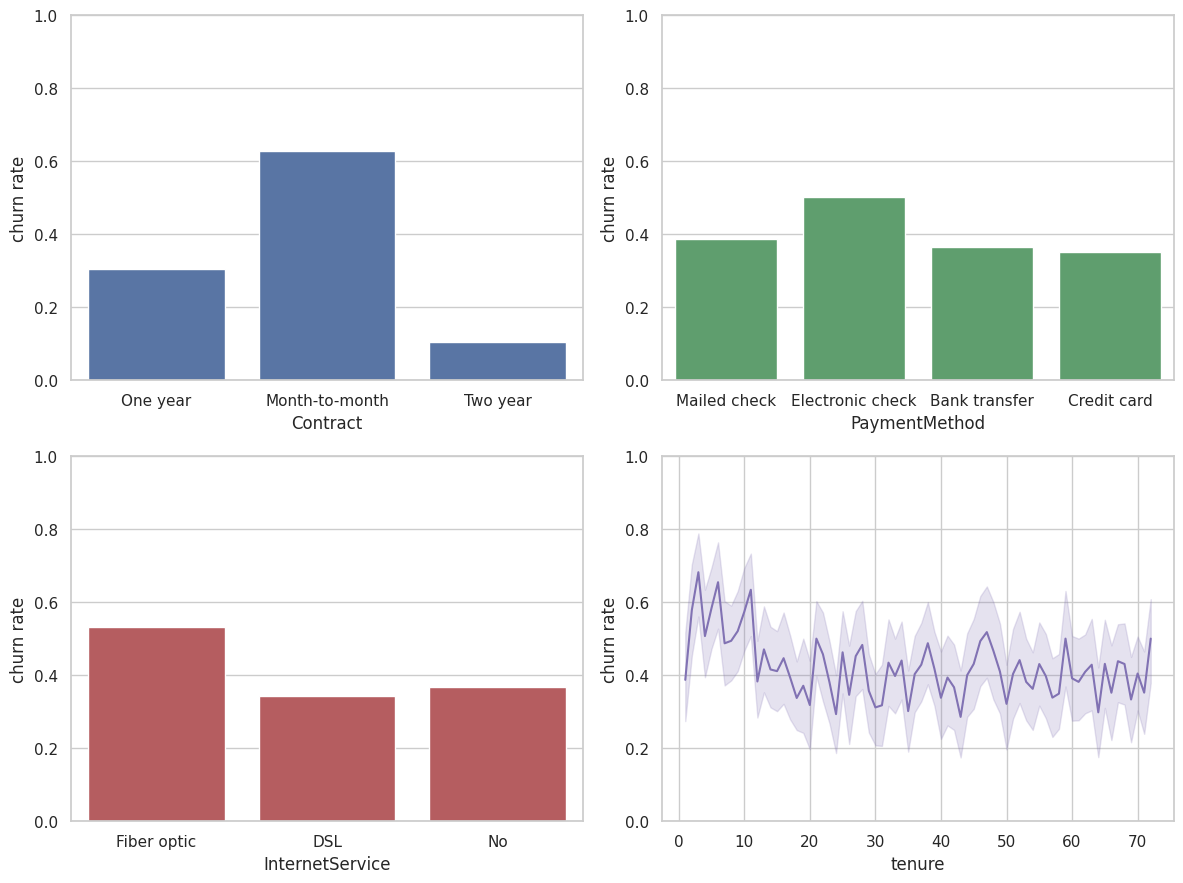

In [4]:
os.makedirs('assets', exist_ok=True)
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
sns.barplot(x='Contract', y='Churn', data=df, ax=axes[0,0], errorbar=None, color='#4C72B0')
sns.barplot(x='PaymentMethod', y='Churn', data=df, ax=axes[0,1], errorbar=None, color='#55A868')
sns.barplot(x='InternetService', y='Churn', data=df, ax=axes[1,0], errorbar=None, color='#C44E52')
sns.lineplot(x='tenure', y='Churn', data=df, ax=axes[1,1], color='#8172B3')
for a in axes.ravel():
    a.set_ylim(0, 1); a.set_ylabel('churn rate')
plt.tight_layout(); plt.savefig('assets/eda.png', dpi=110); plt.show()

## 5. Modeling & Evaluation
We train a `RandomForestClassifier` (class-weighted) and compare to a logistic baseline. We report ROC-AUC (ranking quality), precision/recall/F1, and a confusion matrix. Then we explain the model with **permutation importance** — free and dependency-light.

ROC-AUC : 0.852
Precision: 0.755
Recall   : 0.719
F1       : 0.737
Confusion:
 [[477  99]
 [119 305]]


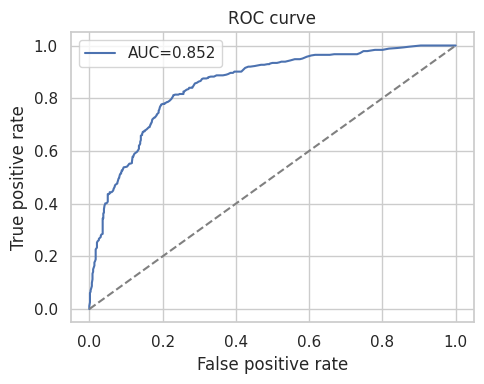

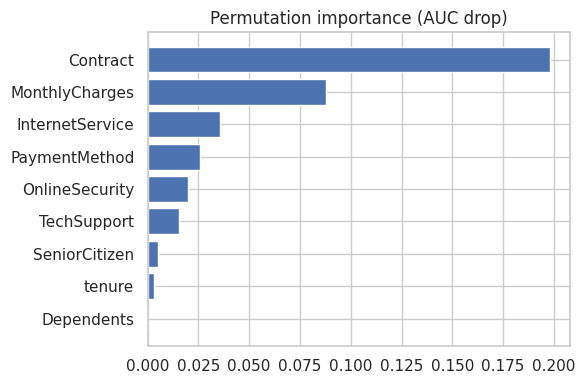

In [5]:
rf = Pipeline([('pre', pre), ('clf', RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced'))])
rf.fit(X_tr, y_tr)
proba = rf.predict_proba(X_te)[:, 1]
pred = (proba >= 0.5).astype(int)

auc = roc_auc_score(y_te, proba)
print('ROC-AUC :', round(auc, 3))
print('Precision:', round(precision_score(y_te, pred), 3))
print('Recall   :', round(recall_score(y_te, pred), 3))
print('F1       :', round(f1_score(y_te, pred), 3))
print('Confusion:\n', confusion_matrix(y_te, pred))

fpr, tpr, _ = roc_curve(y_te, proba)
plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f'AUC={auc:.3f}'); plt.plot([0,1],[0,1],'--', c='gray')
plt.xlabel('False positive rate'); plt.ylabel('True positive rate'); plt.title('ROC curve')
plt.legend(); plt.tight_layout(); plt.savefig('assets/roc.png', dpi=110); plt.show()

from sklearn.inspection import permutation_importance
imp = permutation_importance(rf, X_te, y_te, n_repeats=10, random_state=42, scoring='roc_auc')
order = np.argsort(imp.importances_mean)
plt.figure(figsize=(6,4))
plt.barh([X.columns[i] for i in order], imp.importances_mean[order], color='#4C72B0')
plt.title('Permutation importance (AUC drop)'); plt.tight_layout()
plt.savefig('assets/importance.png', dpi=110); plt.show()

## 6. AI Insights (LLM layer)
An LLM turns the numbers into a stakeholder brief. With `HF_TOKEN` set it calls a free HuggingFace model; otherwise it uses the bundled authored narrative. Either way it writes `insights.md`.

In [6]:
metrics = {
    'project': 'Customer Churn & Retention',
    'audience': 'Retention / CRM team',
    'headline': f"Model flags churn with ROC-AUC {auc:.3f}; {df['Churn'].mean():.0%} of customers churn.",
    'drivers': ['Month-to-month contract', 'Fiber optic internet', 'Electronic-check payment',
                'No TechSupport', 'Tenure under 12 months'],
    'recommendation': 'Rank customers by churn probability; in the first year offer a contract-upgrade incentive plus a free TechSupport/Security trial to the highest-risk segment.',
}
insight_text = generate_insights(metrics)
with open('insights.md', 'w') as f:
    f.write('# AI-Generated Insights — Customer Churn\n\n' + insight_text)
print(insight_text)

## What the data says
Model flags churn with ROC-AUC 0.852; 42% of customers churn.

## Top drivers
- Month-to-month contract
- Fiber optic internet
- Electronic-check payment
- No TechSupport
- Tenure under 12 months

## Recommended action
Rank customers by churn probability; in the first year offer a contract-upgrade incentive plus a free TechSupport/Security trial to the highest-risk segment.

## Why this matters
This turns raw records into a ranked, decision-ready brief — exactly the loop a data analyst owns: question -> data -> model -> plain-English recommendation.


## 7. Recommendations
- Build a **ranked call list** from the churn probability score (don't email everyone).
- Focus first-year effort on **Month-to-month + Fiber + Electronic-check + no-TechSupport** customers.
- Bundle **TechSupport / OnlineSecurity** to lift retention.
- Expected impact: cutting churn by 2pp on a 5k base retains ~100 customers per period — cheaper than acquisition.

This project shows the full analyst loop: a business question, a reproducible dataset, a validated model, explainability, and an AI-written brief a manager can act on.